In [17]:
import mne
import numpy as np
import re

def clean_channel_names(raw):
    mapping = {}
    for ch_name in raw.ch_names:
        # 1. 특수문자 및 불필요한 접미사 제거 (더 강력하게)
        # 예: "EEG Fp1-REF" -> "Fp1", "C3-M1" -> "C3"
        clean_name = re.sub(r'(?i)(EEG|[-_]?(REF|LE|MON|AVG|M1|M2|A1|A2)$)', '', ch_name).strip()
        clean_name = clean_name.upper()
        
        # 2. 표준 이름 매핑 (필요한 경우 추가)
        name_map = {
            'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz', 'OZ': 'Oz',
            'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8',
            'T7': 'T7', 'T8': 'T8' # 이미 표준인 경우 유지
        }
        final_name = name_map.get(clean_name, clean_name.capitalize()) # 나머지는 첫글자만 대문자로
        
        # 원본 이름과 다르면 매핑에 추가
        if ch_name != final_name:
            mapping[ch_name] = final_name

    # 중복 이름 방지 (예: T3->T7로 바꿨는데 이미 T7이 있는 경우)
    # MNE rename_channels는 중복을 허용하지 않으므로, 있는 이름은 제외하고 변경
    final_mapping = {k: v for k, v in mapping.items() if v not in raw.ch_names or k == v}
    
    try:
        raw.rename_channels(final_mapping)
    except Exception as e:
        pass # 이름 변경 실패 시 경고 없이 넘어감 (좌표 매핑에서 걸러짐)
    return raw

def get_valid_channel_indices(raw):
    valid_names = []
    valid_coords = []
    
    # 몽타주 정보에서 좌표 추출
    for ch_name in raw.ch_names:
        if ch_name not in raw.info['chs'][raw.ch_names.index(ch_name)]['ch_name']:
            continue
            
        # MNE 내부 좌표 가져오기
        ch_idx = raw.ch_names.index(ch_name)
        loc = raw.info['chs'][ch_idx]['loc'][:3]
        
        # 좌표가 유효한지 확인 (NaN이 아니고, 0,0,0이 아닌 경우)
        if not np.all(np.isnan(loc)) and not np.all(loc == 0):
            valid_names.append(ch_name)
            valid_coords.append(loc)
            
    return valid_names, valid_coords

unwanted_chs = ['Roc', 'Loc', 'Ekg1', 'Photic', 'Ibi', 'Bursts', 'Suppr']

path = r'D:\One_한양대학교\private object minsu\coding\data\TUAB\v3.0.1\edf\eval\abnormal\01_tcp_ar'
raw = mne.io.read_raw_edf(path + r'\aaaaabdo_s003_t000.edf', preload=False, verbose=False)
raw = clean_channel_names(raw)
raw.drop_channels(unwanted_chs)
raw.pick("eeg", exclude="bads")
# raw.ch_names
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, match_case=False, on_missing='ignore')
valid_names, valid_coords = get_valid_channel_indices(raw)
bb = raw.get_data()
# ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'A1', 'A2', 'Fz', 'Cz', 'Pz', 'Oz']
import mne
import numpy as np
import re

def clean_channel_names(raw):
    mapping = {}
    for ch_name in raw.ch_names:
        # 1. 특수문자 및 불필요한 접미사 제거 (더 강력하게)
        # 예: "EEG Fp1-REF" -> "Fp1", "C3-M1" -> "C3"
        clean_name = re.sub(r'(?i)(EEG|[-_]?(REF|LE|MON|AVG|M1|M2|A1|A2)$)', '', ch_name).strip()
        clean_name = re.sub(r'[^A-Za-z0-9]', '', ch_name).strip().upper()
        # clean_name = clean_name.upper()
        
        # 2. 표준 이름 매핑 (필요한 경우 추가)
        name_map = {
            'FP1': 'Fp1', 'FP2': 'Fp2', 'FZ': 'Fz', 'CZ': 'Cz', 'PZ': 'Pz', 'OZ': 'Oz',
            'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8',
            'T7': 'T7', 'T8': 'T8' # 이미 표준인 경우 유지
        }
        final_name = name_map.get(clean_name, clean_name.capitalize()) # 나머지는 첫글자만 대문자로
        
        # 원본 이름과 다르면 매핑에 추가
        if ch_name != final_name:
            mapping[ch_name] = final_name

    # 중복 이름 방지 (예: T3->T7로 바꿨는데 이미 T7이 있는 경우)
    # MNE rename_channels는 중복을 허용하지 않으므로, 있는 이름은 제외하고 변경
    final_mapping = {k: v for k, v in mapping.items() if v not in raw.ch_names or k == v}
    
    try:
        raw.rename_channels(final_mapping)
    except Exception as e:
        pass # 이름 변경 실패 시 경고 없이 넘어감 (좌표 매핑에서 걸러짐)
    return raw

def get_valid_channel_indices(raw):
    valid_names = []
    valid_coords = []
    
    # 몽타주 정보에서 좌표 추출
    for ch_name in raw.ch_names:
        if ch_name not in raw.info['chs'][raw.ch_names.index(ch_name)]['ch_name']:
            continue
            
        # MNE 내부 좌표 가져오기
        ch_idx = raw.ch_names.index(ch_name)
        loc = raw.info['chs'][ch_idx]['loc'][:3]
        
        # 좌표가 유효한지 확인 (NaN이 아니고, 0,0,0이 아닌 경우)
        if not np.all(np.isnan(loc)) and not np.all(loc == 0):
            valid_names.append(ch_name)
            valid_coords.append(loc)
            
    return valid_names, valid_coords

unwanted_chs = ['Roc', 'Loc', 'Ekg1', 'Photic', 'Ibi', 'Bursts', 'Suppr', 'Ecg ekg', 'Pulse rate', 'Ibi']

# path = r'D:\One_한양대학교\private object minsu\coding\data\TUAB\v3.0.1\edf\train\abnormal\01_tcp_ar'
# raw = mne.io.read_raw_edf(path + r'\aaaaaaaq_s004_t000.edf', preload=False, verbose=False)
# raw = mne.io.read_raw_edf(path + r'\aaaaajsl_s010_t000.edf', preload=False, verbose=False)


path = r'D:\open_eeg_eval\physionet_MI\S001'
raw = mne.io.read_raw_edf(path + r'\S001R03.edf', preload=False, verbose=False)

raw = clean_channel_names(raw)
print(raw.ch_names)
raw.drop_channels([f for f in unwanted_chs if f in raw.ch_names])
raw.pick("eeg", exclude="bads")
# raw.ch_names
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, match_case=False, on_missing='ignore')
print(raw.ch_names)
valid_names, valid_coords = get_valid_channel_indices(raw)
bb = raw.get_data()
# ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'A1', 'A2', 'Fz', 'Cz', 'Pz', 'Oz']
# ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'A1', 'A2', 'Fz', 'Cz', 'Pz']
print(raw.ch_names)
print(valid_names)
raw.get_data()[-1]

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7

array([-2.8e-05, -4.0e-05, -3.7e-05, ...,  0.0e+00,  0.0e+00,  0.0e+00])

In [18]:
mne.events_from_annotations(raw, )

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


(array([[    0,     0,     1],
        [  672,     0,     3],
        [ 1328,     0,     1],
        [ 2000,     0,     2],
        [ 2656,     0,     1],
        [ 3328,     0,     2],
        [ 3984,     0,     1],
        [ 4656,     0,     3],
        [ 5312,     0,     1],
        [ 5984,     0,     3],
        [ 6640,     0,     1],
        [ 7312,     0,     2],
        [ 7968,     0,     1],
        [ 8640,     0,     2],
        [ 9296,     0,     1],
        [ 9968,     0,     3],
        [10624,     0,     1],
        [11296,     0,     2],
        [11952,     0,     1],
        [12624,     0,     3],
        [13280,     0,     1],
        [13952,     0,     3],
        [14608,     0,     1],
        [15280,     0,     2],
        [15936,     0,     1],
        [16608,     0,     2],
        [17264,     0,     1],
        [17936,     0,     3],
        [18592,     0,     1],
        [19264,     0,     2]]),
 {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3})

In [5]:
import pandas as pd
import numpy as np
path = r"D:\open_eeg_eval\ISRUC\dataset\Non_Events\non_event_batch_1\S1_p1_Stagen1_Event10_Session1.csv"
df = pd.read_csv(path)
df = np.array([df['C3-A2'], df['F3-A2']])

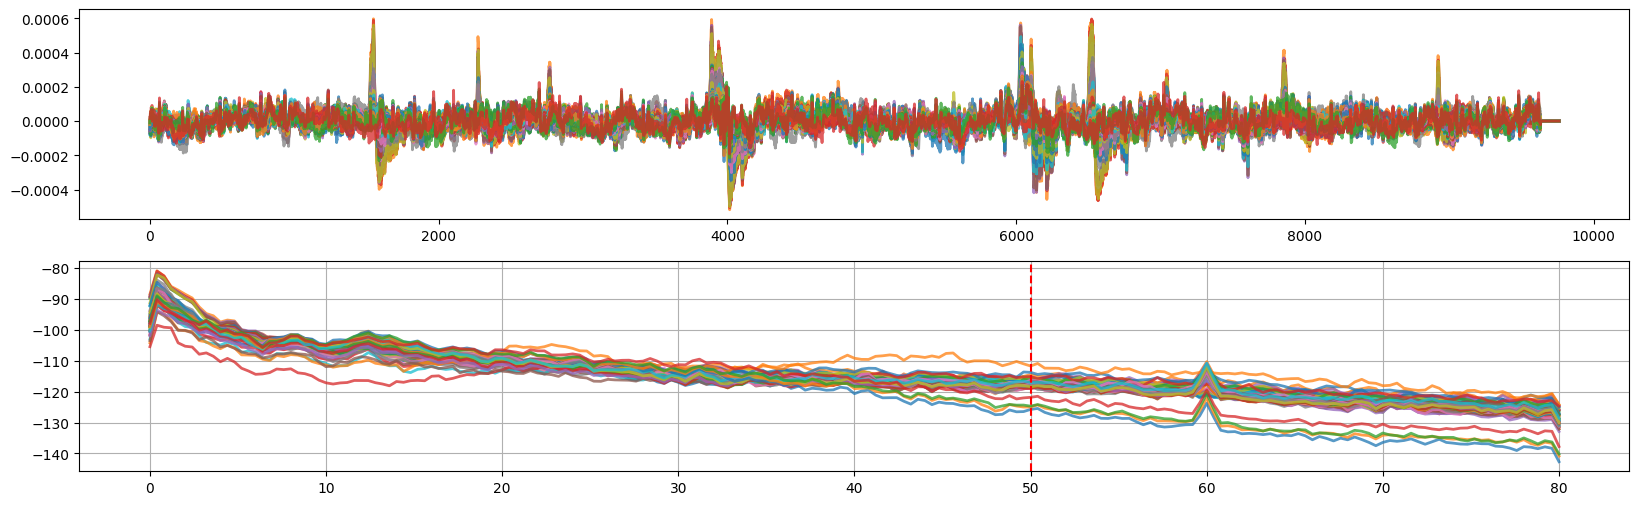

In [11]:
import matplotlib.pyplot as plt
from scipy import signal
plt.figure(figsize=(20,6))
plt.subplot(211)
plt.plot(bb[:, 200*0:200*60].T, alpha=0.75, lw=2) ############### 여기서 index 바꾸면 세그먼트 내 구간 plot 가능
plt.subplot(212)
freqs, psd = signal.welch(bb, fs=raw.info['sfreq'], nperseg=200*2, axis=-1)
# psd = np.mean(psd, axis=0)) ############### 이거 주석 풀면 mean psd 볼 수 있음 
plt.plot(freqs, (10 * np.log10(psd)).T, alpha=0.75, lw=2)
plt.axvline(x=50, color='r', linestyle='--')
plt.grid()
print()

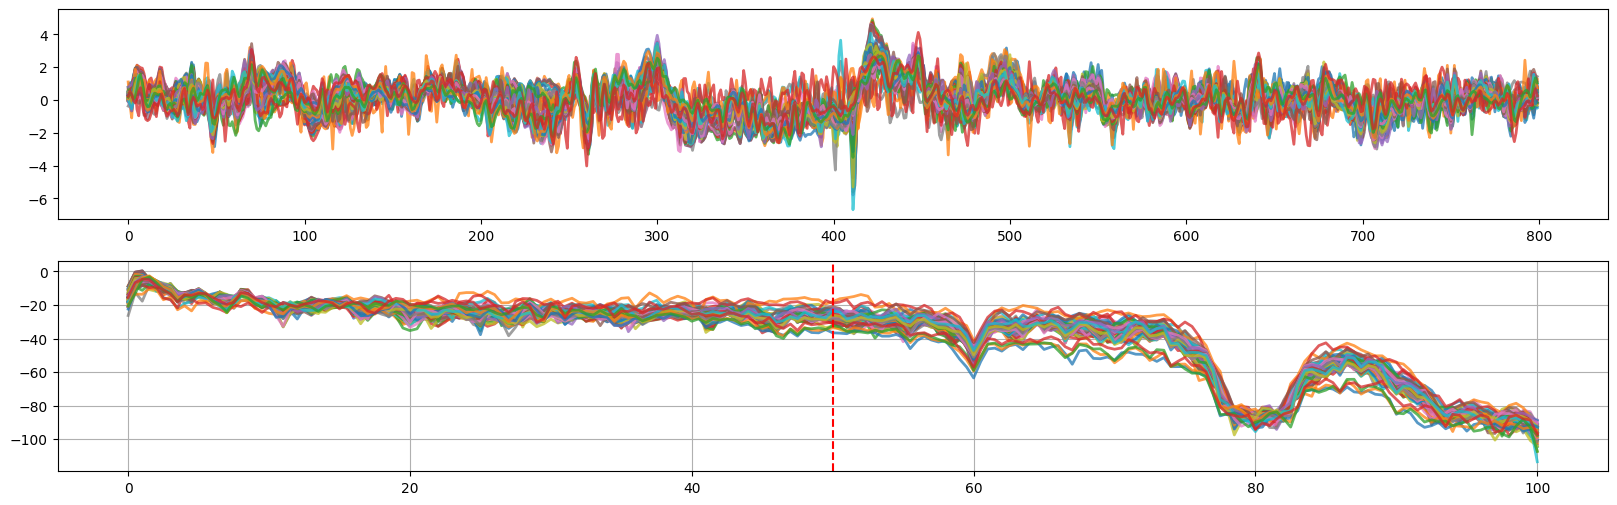

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

path = r"D:\open_eeg_eval\PhysioNetMI_npy\train\eeg.npy"
data = np.load(path)
bb = data[0]
plt.figure(figsize=(20,6))
plt.subplot(211)
plt.plot(bb[:, 200*0:200*60].T, alpha=0.75, lw=2) ############### 여기서 index 바꾸면 세그먼트 내 구간 plot 가능
plt.subplot(212)
freqs, psd = signal.welch(bb, fs=200, nperseg=200*2, axis=-1)
# psd = np.mean(psd, axis=0)) ############### 이거 주석 풀면 mean psd 볼 수 있음 
plt.plot(freqs, (10 * np.log10(psd)).T, alpha=0.75, lw=2)
plt.axvline(x=50, color='r', linestyle='--')
plt.grid()
print()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

path = r"D:\open_eeg_eval\PhysioNetMI_npz\test.npz"
data = np.load(path)
data['coords'][0].shape, data['coords'][0]

((64, 3),
 array([[-0.0789  ,  0.05136 ,  0.063   ],
        [-0.06186 ,  0.05713 ,  0.09375 ],
        [-0.0357  ,  0.0617  ,  0.118   ],
        [-0.001271,  0.0635  ,  0.1266  ],
        [ 0.03314 ,  0.06183 ,  0.11676 ],
        [ 0.06064 ,  0.0577  ,  0.0938  ],
        [ 0.0778  ,  0.0521  ,  0.06287 ],
        [-0.0821  ,  0.01929 ,  0.0695  ],
        [-0.06714 ,  0.02336 ,  0.1045  ],
        [-0.03793 ,  0.02634 ,  0.1298  ],
        [-0.001374,  0.02762 ,  0.1403  ],
        [ 0.0359  ,  0.02635 ,  0.1284  ],
        [ 0.0653  ,  0.02357 ,  0.1037  ],
        [ 0.08167 ,  0.0197  ,  0.06946 ],
        [-0.08154 , -0.01334 ,  0.0731  ],
        [-0.0655  , -0.011894,  0.1078  ],
        [-0.0374  , -0.010826,  0.1334  ],
        [-0.001525, -0.01052 ,  0.1416  ],
        [ 0.03647 , -0.0109  ,  0.1328  ],
        [ 0.0647  , -0.01199 ,  0.1077  ],
        [ 0.0814  , -0.01346 ,  0.07336 ],
        [-0.0309  ,  0.11456 ,  0.02786 ],
        [-0.001337,  0.1191  ,  0.0329  ],
 